In [1]:
import os,sys,subprocess,glob,importlib,pickle,itertools,string
from datetime import datetime
import xarray as xr
import numpy as np
import pandas as pd
import scipy,math


from sup.sup_plotting import *
from sup.ensemble_bootstrapping import *
from sup.useful_functions import *
from ridge_regression.ridge_functions import *

from pickles.load_pickle_1D import *

%load_ext autoreload
%autoreload 2

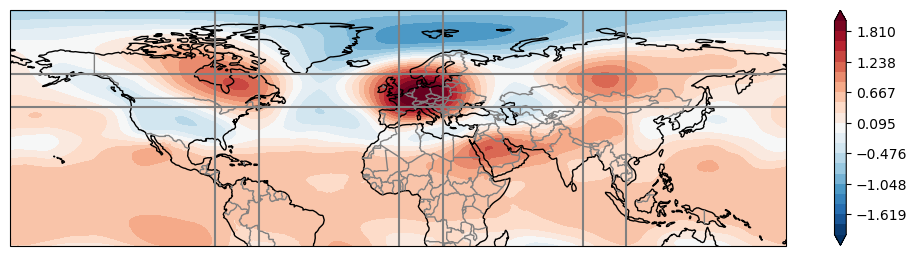

In [2]:
var = 'zg500'
a = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_rea_100.nc').squeeze()
b = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_LE_average.nc').squeeze()
c = xr.load_dataarray(f'std_maps/{var}_piControl_LE_std.nc').squeeze()

xx = a.copy()
xx.values = (a.values - b.values) / c.values 

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection":cartopy.crs.PlateCarree()})
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, edgecolor='gray')
im = ax.contourf(xx.lon, xx.lat, xx, transform=cartopy.crs.PlateCarree(), cmap='RdBu_r', levels=np.linspace(-2,2,22), extend='both')
ax.axhline(45, color='gray')
ax.axhline(60, color='gray')
for center_lon in [10,-75,95]:
    ax.axvline(center_lon-10, color='gray')
    ax.axvline(center_lon+10, color='gray')

plt.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout()

In [3]:
    cmap = matplotlib.colormaps["RdBu_r"]
    cmap.set_under("c")   # color for values < vmin
    cmap.set_over("m")  


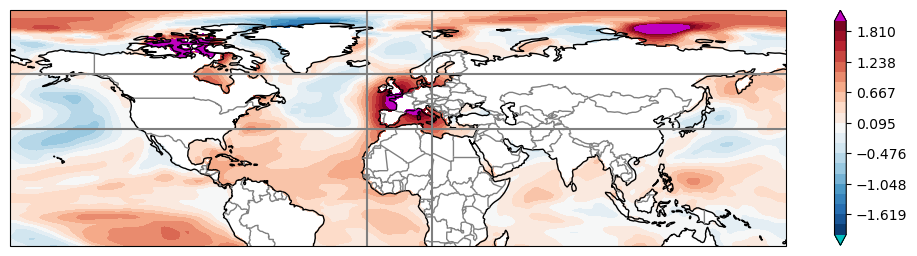

In [13]:
var = 'tos'
a = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_rea_100.nc').squeeze()
b = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_initial_average.nc').squeeze()
c = xr.load_dataarray(f'std_maps/{var}_piControl-initial_std.nc').squeeze()

xx = a.copy()
xx.values = (a.values - b.values) / c.values 

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection":cartopy.crs.PlateCarree()})
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, edgecolor='gray')
im = ax.contourf(xx.lon, xx.lat, xx, transform=cartopy.crs.PlateCarree(), cmap=cmap, levels=np.linspace(-2,2,22), extend='both')
ax.axhline(35, color='gray')
ax.axhline(60, color='gray')
ax.axvline(-15, color='gray')
ax.axvline(15, color='gray')

plt.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout()

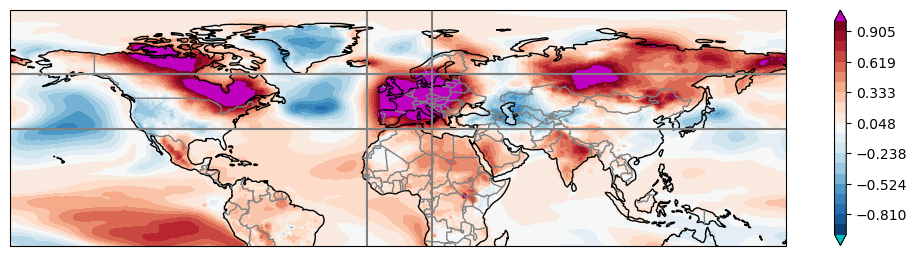

In [ ]:
var = 'tas'
a = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_rea_100.nc').squeeze()
b = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_LE_average.nc').squeeze()
c = xr.load_dataarray(f'std_maps/{var}_piControl_LE_std.nc').squeeze()

xx = a.copy()
xx.values = (a.values - b.values)# / c.values 

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection":cartopy.crs.PlateCarree()})
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, edgecolor='gray')
im = ax.contourf(xx.lon, xx.lat, xx, transform=cartopy.crs.PlateCarree(), cmap=cmap, levels=np.linspace(-1,1,22), extend='both')
ax.axhline(35, color='gray')
ax.axhline(60, color='gray')
ax.axvline(-15, color='gray')
ax.axvline(15, color='gray')

plt.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout()

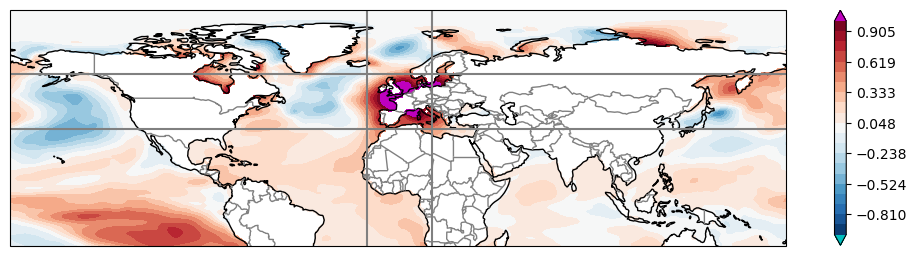

In [21]:
var = 'tos'
a = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_rea_100.nc').squeeze()
b = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_initial_average.nc').squeeze()
c = xr.load_dataarray(f'std_maps/{var}_piControl_LE_std.nc').squeeze()

xx = a.copy()
xx.values = (a.values - b.values)# / c.values 

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection":cartopy.crs.PlateCarree()})
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, edgecolor='gray')
im = ax.contourf(xx.lon, xx.lat, xx, transform=cartopy.crs.PlateCarree(), cmap=cmap, levels=np.linspace(-1,1,22), extend='both')
ax.axhline(35, color='gray')
ax.axhline(60, color='gray')
ax.axvline(-15, color='gray')
ax.axvline(15, color='gray')

plt.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout()

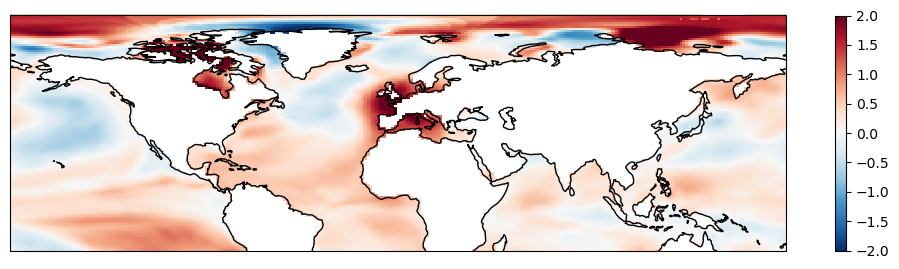

In [24]:
a = xr.load_dataarray(f'average_maps/tos_ssp370-2025_rea_100.nc').squeeze()
b = xr.load_dataarray(f'average_maps/tos_ssp370-2025_initial_average.nc').squeeze()
c = xr.load_dataarray(f'std_maps/tos_piControl_LE_std.nc').squeeze()

xx = a.copy()
xx.values = (a.values - b.values) / c.values 

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection":cartopy.crs.PlateCarree()})
ax.coastlines()
im = ax.pcolormesh(xx.lon, xx.lat, xx, transform=cartopy.crs.PlateCarree(), cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout()

## maps for paper

In [62]:
def plot_together(extent=None, pixels=False, axes=None):
    cmap = matplotlib.colormaps["RdBu_r"]
    cmap.set_under("c")   # color for values < vmin
    cmap.set_over("m")  

    if axes is None:
        nrows = int(len(details)/2)
        ncols = 2
        fig,axes = plt.subplots(nrows=nrows, ncols=ncols+1, figsize=(ncols*6,nrows*2), 
                                subplot_kw={"projection":cartopy.crs.PlateCarree()}, gridspec_kw=dict(width_ratios = [10,10,1]))

    for row, col, var,label,maxabs,a_name, b_name in details:

        a = xr.load_dataarray(f'average_maps/{var}_{a_name}.nc').squeeze().sel(dict(lat=slice(-20,91)))
        b = xr.load_dataarray(f'average_maps/{var}_{b_name}.nc').squeeze().sel(dict(lat=slice(-20,91)))
        b_climate = b_name.split('_')[0]
        b_ens = b_name.split('_')[1]
        st = xr.load_dataarray(f"std_maps/{var}_{b_climate}_{b_ens}_std.nc").squeeze().sel(dict(lat=slice(-20,91)))

        xxx = (a - b.values) / st.values
        xxx = xxx
        ax = axes[row,col]
        ax.coastlines(linewidth=0.3, color='gray')
        if extent is not None:
            ax.set_extent(extent)
        levels = np.linspace(-maxabs,maxabs,24)
        if pixels:
            im = ax.pcolormesh(xxx.lon, xxx.lat, xxx, transform=cartopy.crs.PlateCarree(), vmin=-maxabs, vmax=maxabs, cmap=cmap)
        else:
            im = ax.contourf(xxx.lon, xxx.lat, xxx, transform=cartopy.crs.PlateCarree(), levels=levels, extend='both' , cmap=cmap)

        ax.add_patch(matplotlib.patches.Rectangle(xy=[-4, 44], width=16, height=11, facecolor='none', edgecolor='k', transform=cartopy.crs.PlateCarree()))

        t = ax.annotate(string.ascii_lowercase[col+row*2], xy=(0,1), xycoords="axes fraction", va='center', ha='center', clip_on=False, fontsize=15)
        t.set_bbox(dict(facecolor='w', edgecolor='none'))

        if col == 1:
            axes[row,-1].axis('off')
            cbar = plt.colorbar(im, ax=axes[row,-1], label=label)
            cbar.set_ticks(np.linspace(-maxabs,maxabs,6))

    return axes


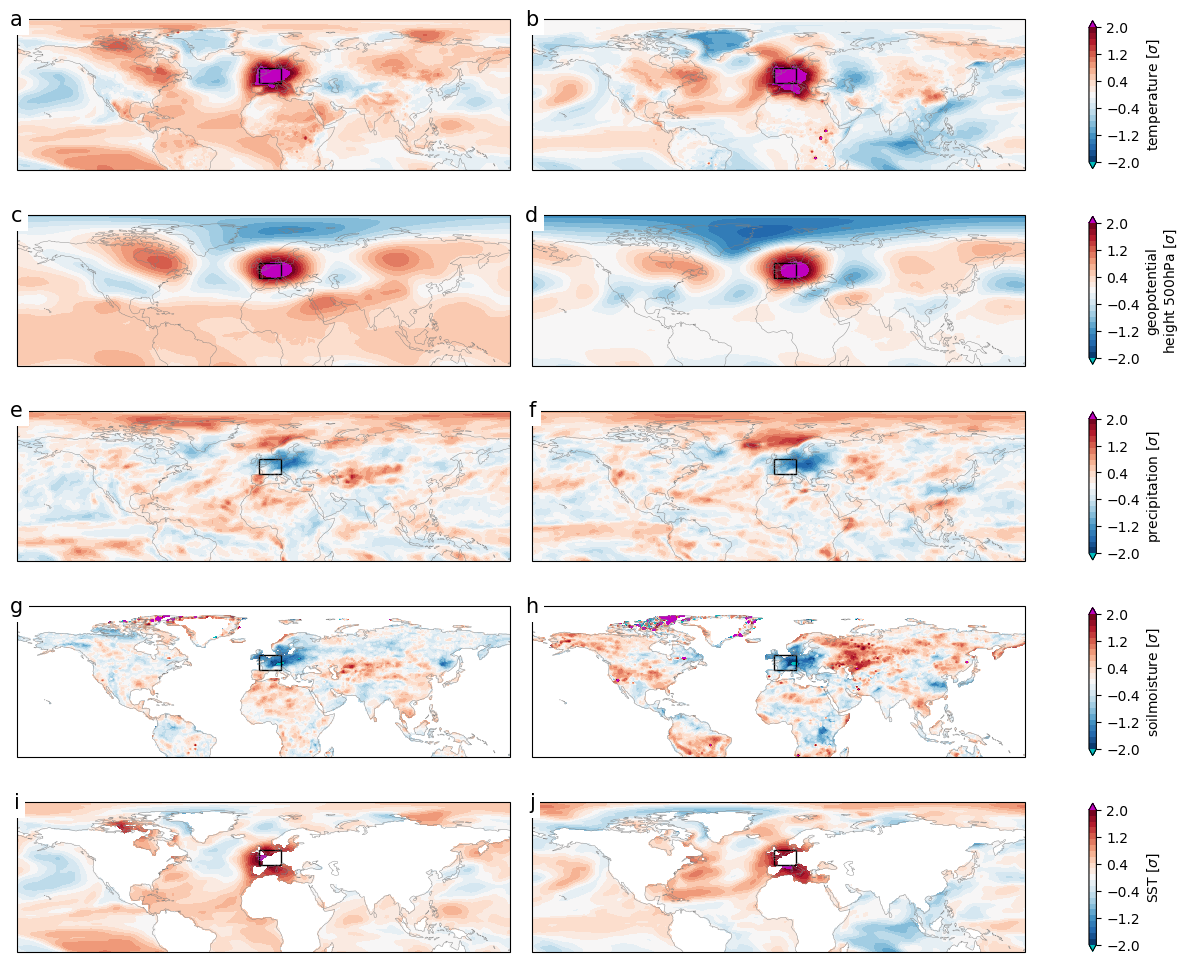

In [43]:
rt = 100

details = [
    (0, 0, 'tas', 'temperature [$\sigma$]', 2, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_average'),
    (1, 0, 'zg500', 'geopotential\nheight 500hPa [$\sigma$]', 2, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_average'),
    (2, 0, 'pr', 'precipitation [$\sigma$]', 2, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_average'),
    (3, 0, 'mrsos', 'soilmoisture [$\sigma$]', 2, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_average'),
    (4, 0, 'tos', 'SST [$\sigma$]', 2, f'ssp370-2025_rea_{rt}', f'ssp370-2025_initial_average'),
    (0, 1, 'tas', 'temperature [$\sigma$]', 2, f'piControl_rea_{rt}', f'piControl_LE_average'),
    (1, 1, 'zg500', 'geopotential\nheight 500hPa [$\sigma$]', 2, f'piControl_rea_{rt}', f'piControl_LE_average'),
    (2, 1, 'pr', 'precipitation [$\sigma$]', 2, f'piControl_rea_{rt}', f'piControl_LE_average'),
    (3, 1, 'mrsos', 'soilmoisture [$\sigma$]', 2, f'piControl_rea_{rt}', f'piControl_LE_average'),
    (4, 1, 'tos', 'SST [$\sigma$]', 2, f'piControl_rea_{rt}', f'piControl_initial_average'),
    ]


axes = plot_together()
#axes[0,0].set_title('ssp370-2025\n100-year vs average summers')
#axes[0,1].set_title('piControl\n100-year vs average summers')
plt.tight_layout()
savefig(f'diff_maps/diff_maps_all_{rt}')

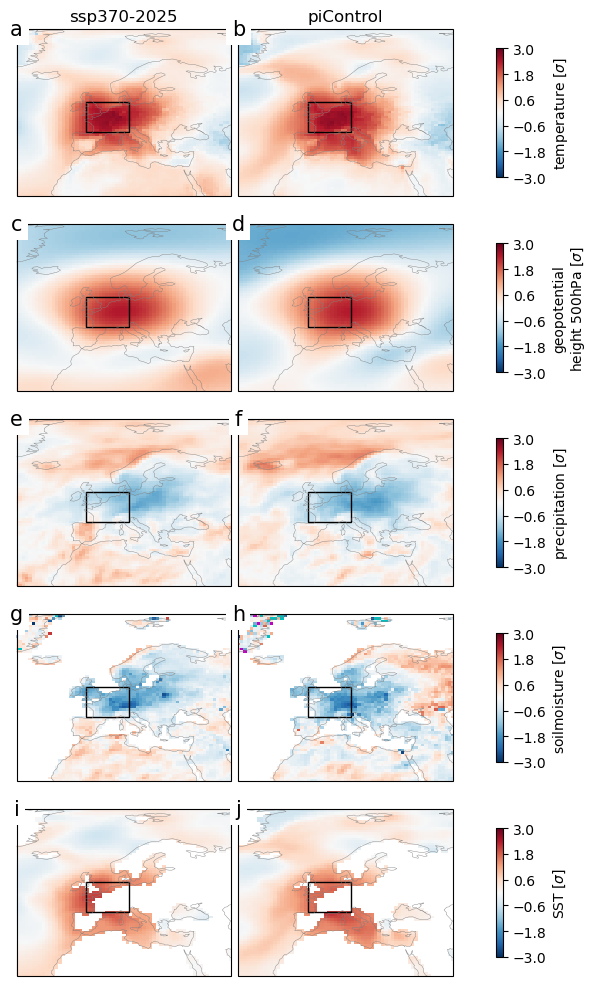

In [71]:
rt = 100

details = [
    (0, 0, 'tas', 'temperature [$\sigma$]', 3, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_average'),
    (1, 0, 'zg500', 'geopotential\nheight 500hPa [$\sigma$]', 3, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_average'),
    (2, 0, 'pr', 'precipitation [$\sigma$]', 3, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_average'),
    (3, 0, 'mrsos', 'soilmoisture [$\sigma$]', 3, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_average'),
    (4, 0, 'tos', 'SST [$\sigma$]', 3, f'ssp370-2025_rea_{rt}', f'ssp370-2025_initial_average'),
    (0, 1, 'tas', 'temperature [$\sigma$]', 3, f'piControl_rea_{rt}', f'piControl_LE_average'),
    (1, 1, 'zg500', 'geopotential\nheight 500hPa [$\sigma$]', 3, f'piControl_rea_{rt}', f'piControl_LE_average'),
    (2, 1, 'pr', 'precipitation [$\sigma$]', 3, f'piControl_rea_{rt}', f'piControl_LE_average'),
    (3, 1, 'mrsos', 'soilmoisture [$\sigma$]', 3, f'piControl_rea_{rt}', f'piControl_LE_average'),
    (4, 1, 'tos', 'SST [$\sigma$]', 3, f'piControl_rea_{rt}', f'piControl_initial_average'),
    ]


fig,axes = plt.subplots(nrows=5, ncols=3, figsize=(6,10), 
                        subplot_kw={"projection":cartopy.crs.PlateCarree()}, gridspec_kw=dict(width_ratios = [10,10,2]))

axes = plot_together(extent=[-30,50,20,80], pixels=True, axes=axes)
axes[0,0].set_title('ssp370-2025')
axes[0,1].set_title('piControl')
plt.tight_layout()

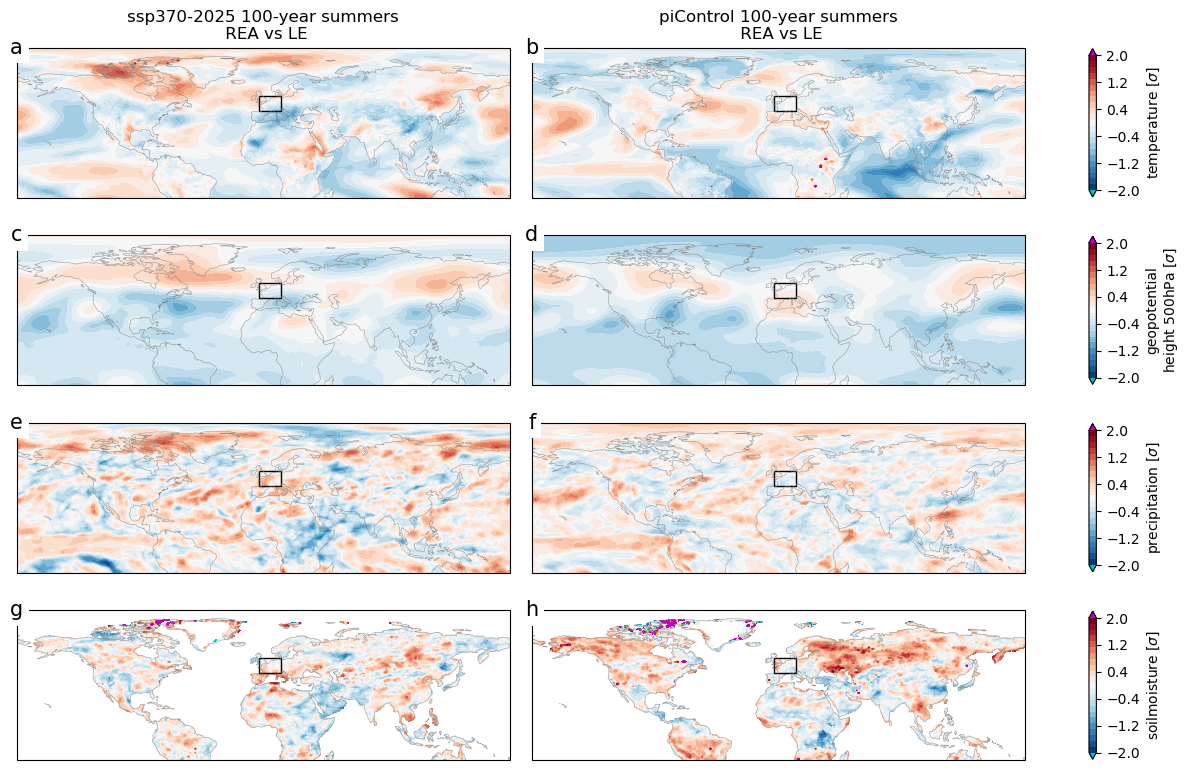

In [44]:
rt = 100

details = [
    (0, 0, 'tas', 'temperature [$\sigma$]', 2, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_{rt}'),
    (1, 0, 'zg500', 'geopotential\nheight 500hPa [$\sigma$]', 2, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_{rt}'),
    (2, 0, 'pr', 'precipitation [$\sigma$]', 2, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_{rt}'),
    (3, 0, 'mrsos', 'soilmoisture [$\sigma$]', 2, f'ssp370-2025_rea_{rt}', f'ssp370-2025_LE_{rt}'),
    (0, 1, 'tas', 'temperature [$\sigma$]', 2, f'piControl_rea_{rt}', f'piControl_LE_{rt}'),
    (1, 1, 'zg500', 'geopotential\nheight 500hPa [$\sigma$]', 2, f'piControl_rea_{rt}', f'piControl_LE_{rt}'),
    (2, 1, 'pr', 'precipitation [$\sigma$]', 2, f'piControl_rea_{rt}', f'piControl_LE_{rt}'),
    (3, 1, 'mrsos', 'soilmoisture [$\sigma$]', 2, f'piControl_rea_{rt}', f'piControl_LE_{rt}'),
    ]


axes = plot_together()
axes[0,0].set_title('ssp370-2025 100-year summers\n REA vs LE')
axes[0,1].set_title('piControl 100-year summers\n REA vs LE')
plt.tight_layout()
savefig(f'diff_maps/diff_maps_rea_vs_LE_{rt}')

## Dry vs rea345 z500

/tmp/ipykernel_43752/3967363296.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_43752/3967363296.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


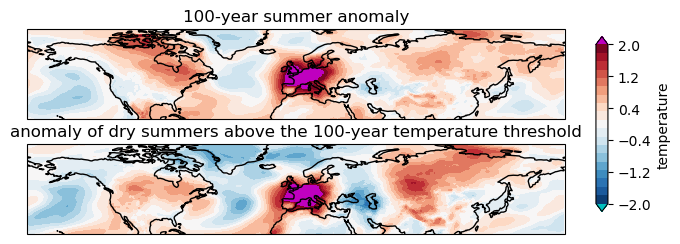

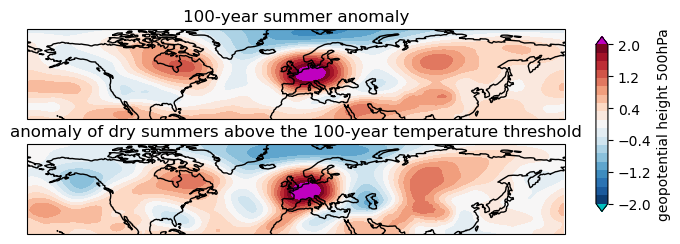

In [37]:
cmap = matplotlib.colormaps["RdBu_r"]
cmap.set_under("c")
cmap.set_over("m")  

for r,var,label,maxabs,_ in [
        (0, 'tas', 'temperature', 2, False),
        (1, 'zg500', 'geopotential height 500hPa', 2, False),
        #(2, 'pr', 'precipitation', 2, False),
        #(3, 'mrsos', 'soilmoisture', 2, False),
        #(4, 'tos', 'SST', 2, True),
        ]:
    
    fig,axes = plt.subplots(nrows=2, figsize=(6,2.5), subplot_kw={"projection":cartopy.crs.PlateCarree()})
    for ax in axes:
        ax.coastlines()
        ax.set_extent([-180,180,20,80])

    ref = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_initial_average.nc').squeeze()
    rea_dry = xr.load_dataarray(f'average_maps/{var}_ssp370-2025-dry_rea_100.nc').squeeze()
    rea = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_rea_100.nc').squeeze()
    std = xr.load_dataarray(f'std_maps/{var}_piControl_LE_std.nc').squeeze()

    levels = np.linspace(-maxabs, maxabs, 20)

    xx = ref.copy()
    axes[0].set_title('100-year summer anomaly')
    xx.values = (rea.values - ref.values) / std.values 
    im = axes[0].contourf(xx.lon, xx.lat, xx, transform=cartopy.crs.PlateCarree(), cmap=cmap, levels=levels, extend='both')
    axes[1].set_title('anomaly of dry summers above the 100-year temperature threshold')
    xx.values = (rea_dry.values - ref.values) / std.values 
    im = axes[1].contourf(xx.lon, xx.lat, xx, transform=cartopy.crs.PlateCarree(), cmap=cmap, levels=levels, extend='both')

    cax = fig.add_axes([1, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, location='right', cax=cax, label=label, shrink=0.9)
    cbar.set_ticks(np.linspace(-maxabs,maxabs,6))

    plt.tight_layout()
    savefig(f'diff_maps/current_100-year_REA_vs_dry_{var}', bbox_inches='tight')

## SST in June and Aug

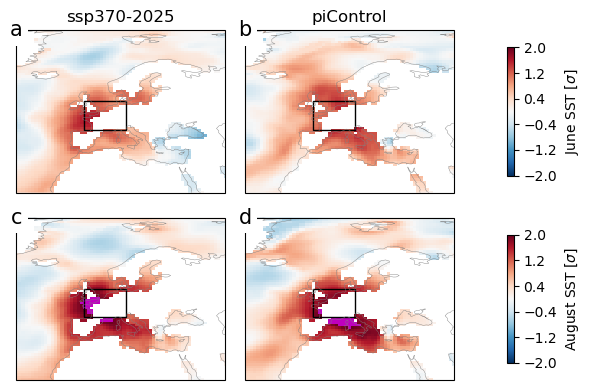

In [69]:
rt = 100

details = [
    (0, 0, 'tos', 'June SST [$\sigma$]', 2, f'ssp370-2025_rea_{rt}_jun', f'ssp370-2025_initial_average_jun'),
    (0, 1, 'tos', 'June SST [$\sigma$]', 2, f'piControl_rea_{rt}_jun', f'piControl_initial_average_jun'),
    (1, 0, 'tos', 'August SST [$\sigma$]', 2, f'ssp370-2025_rea_{rt}_aug', f'ssp370-2025_initial_average_aug'),
    (1, 1, 'tos', 'August SST [$\sigma$]', 2, f'piControl_rea_{rt}_aug', f'piControl_initial_average_aug'),
    ]

fig,axes = plt.subplots(nrows=2, ncols=3, figsize=(6,4), 
                        subplot_kw={"projection":cartopy.crs.PlateCarree()}, gridspec_kw=dict(width_ratios = [10,10,2]))

axes = plot_together(extent=[-30,50,20,80], pixels=True, axes=axes)
axes[0,0].set_title('ssp370-2025')
axes[0,1].set_title('piControl')
plt.tight_layout()
savefig(f'diff_maps/diff_map_sst_100_jun_aug')

## Problem with SSTs from LE

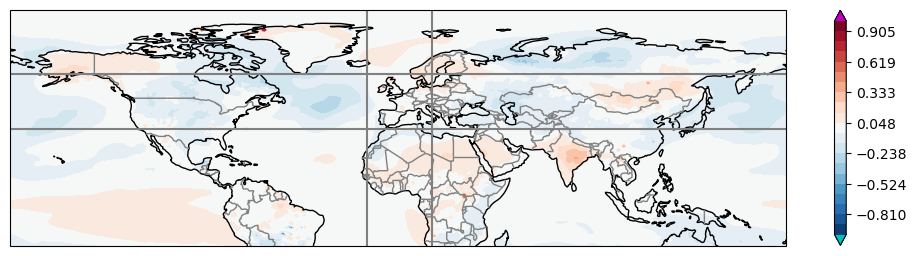

In [ ]:
var = 'tas'
a = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_initial_average.nc').squeeze()
b = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_LE_average.nc').squeeze()
c = xr.load_dataarray(f'std_maps/{var}_piControl_LE_std.nc').squeeze()

xx = a.copy()
xx.values = (a.values - b.values)# / c.values 

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection":cartopy.crs.PlateCarree()})
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, edgecolor='gray')
im = ax.contourf(xx.lon, xx.lat, xx, transform=cartopy.crs.PlateCarree(), cmap=cmap, levels=np.linspace(-1,1,22), extend='both')
ax.axhline(35, color='gray')
ax.axhline(60, color='gray')
ax.axvline(-15, color='gray')
ax.axvline(15, color='gray')

plt.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout()

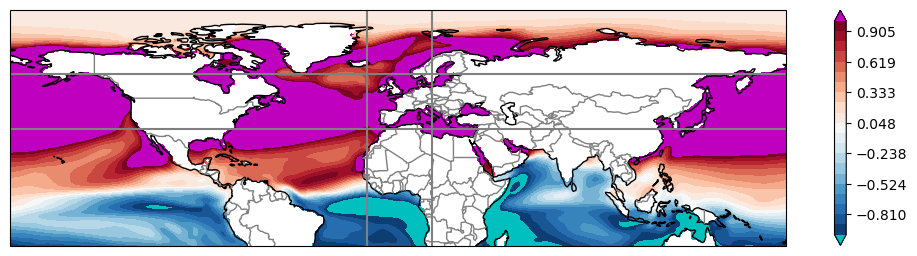

In [ ]:
var = 'tos'
a = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_initial_average.nc').squeeze()
b = xr.load_dataarray(f'average_maps/{var}_ssp370-2025_LE_average.nc').squeeze()
c = xr.load_dataarray(f'std_maps/{var}_piControl_LE_std.nc').squeeze()

xx = a.copy()
xx.values = (a.values - b.values)# / c.values 

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection":cartopy.crs.PlateCarree()})
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, edgecolor='gray')
im = ax.contourf(xx.lon, xx.lat, xx, transform=cartopy.crs.PlateCarree(), cmap=cmap, levels=np.linspace(-1,1,22), extend='both')
ax.axhline(35, color='gray')
ax.axhline(60, color='gray')
ax.axvline(-15, color='gray')
ax.axvline(15, color='gray')

plt.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout()